# Stage 4: bounded tuning, interpretation and model choice

This notebook uses the approved Stage 3 baseline, unchanged 27 predictors and saved five-fold development manifests. It is development selection evidence, not independent test performance. Holdout remains protected. Search settings are in `src/models/configs/stage4_search.json`; measured comparisons and the frozen selection are under `artifacts/metrics/stage4-selection-v1/`. Setup and read-only verification commands are in notebook 05.

The course/tutorial sequence is whole-pipeline CV → bounded complexity comparison → error/feature interpretation → development-only threshold choice → freeze before holdout. No history, resampling, calibration or additional voting/stacking ensemble is introduced.

Build from a completed local Stage 3 run with `python -m src.models.stage4`. From a compact checkout, explicitly use `python -m src.models.stage4 --rebuild-baseline`: this preserves the compact baseline under `archive/`, rebuilds its missing intermediates and checks baseline metric parity before Stage 4. To rebuild an existing compact Stage 4 run, first preserve/move that entire run outside active artifacts; existing runs are never overwritten. Read-only compact inspection is `python -m src.models.stage4_checkpoint`. It verifies published evidence, not omitted predictions/models.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/models/configs/stage4_search.json').exists())
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.models.verify_stage4 import verify
from src.models.stage4_checkpoint import verify_checkpoint
RUN = ROOT / 'artifacts/metrics/stage4-selection-v1'
assert RUN.exists(), 'Run python -m src.models.stage4 with the predeclared config first; never overwrite an existing run.'
config = json.loads((RUN / 'configuration.json').read_text())
selection = json.loads((RUN / 'selection_record.json').read_text())
policy = json.loads((RUN / 'decision_policy.json').read_text())
assert selection['holdout_evaluated'] is False
print('Development only. Feature v1.1, contract v1.2, split v1.1. No holdout evaluation.')


Development only. Feature v1.1, contract v1.2, split v1.1. No holdout evaluation.


## Predeclared scope and fair comparisons

Shrinkage challenges unstable correlated/rare-level coefficients. Tree depth/leaf/pruning tests bias–variance. Bootstrap/feature-randomized forests challenge single-tree instability. No-payment and item-bearing-only sensitivities challenge record/snapshot assumptions. They do not silently change primary features or target cohorts.

Selection minimizes fold-mean MAE or maximizes fold-mean AP, preferring a simpler family within 0.02 days or 0.002 AP. Those margins are practical conventions, not statistical significance or validated business utility. Ninety-five new search fits, ten selected diagnostic fits and fifteen sensitivity fits are budgeted. Prior baseline fits are reused, not falsely counted as newly executed.


In [2]:
for task in ['regression', 'classification']:
    print(task, 'primary metric:', config['primary_metrics'][task])
    display(pd.DataFrame(config[f'{task}_candidates']))
print('Maximum fits:', config['max_fits'], 'workers:', config['n_jobs'], 'seed:', config['seed'])
verification = verify(RUN) if (RUN / 'candidate_oof_predictions.csv').exists() else verify_checkpoint(RUN)
assert verification['holdout_evaluated'] is False


regression primary metric: mae


,family,id,params
0,ridge,ridge_a1,"{'alpha': 1.0, 'solver': 'lsqr', 'tol': 1e-06}"
1,ridge,ridge_a100,"{'alpha': 100.0, 'solver': 'lsqr', 'tol': 1e-06}"
2,tree,tree_d3_l200,"{'ccp_alpha': 0.0, 'max_depth': 3, 'min_sample..."
3,tree,tree_d8_l50,"{'ccp_alpha': 0.0, 'max_depth': 8, 'min_sample..."
4,tree,tree_d12_l20,"{'ccp_alpha': 0.0, 'max_depth': 12, 'min_sampl..."
5,tree,tree_d12_l20_pruned,"{'ccp_alpha': 0.05, 'max_depth': 12, 'min_samp..."
6,forest,forest_d8_l50_sqrt,"{'bootstrap': True, 'max_depth': 8, 'max_featu..."
7,forest,forest_d12_l20_half,"{'bootstrap': True, 'max_depth': 12, 'max_feat..."
8,forest,forest_d16_l20_half,"{'bootstrap': True, 'max_depth': 16, 'max_feat..."


classification primary metric: average_precision


,family,id,params
0,logistic,logistic_c001,"{'C': 0.01, 'class_weight': None, 'max_iter': ..."
1,logistic,logistic_c01,"{'C': 0.1, 'class_weight': None, 'max_iter': 2..."
2,logistic,logistic_c1,"{'C': 1.0, 'class_weight': None, 'max_iter': 2..."
3,tree,tree_d3_l200,"{'ccp_alpha': 0.0, 'max_depth': 3, 'min_sample..."
4,tree,tree_d8_l50,"{'ccp_alpha': 0.0, 'max_depth': 8, 'min_sample..."
5,tree,tree_d12_l20,"{'ccp_alpha': 0.0, 'max_depth': 12, 'min_sampl..."
6,tree,tree_d12_l20_pruned,"{'ccp_alpha': 0.0005, 'max_depth': 12, 'min_sa..."
7,forest,forest_d8_l50_sqrt,"{'bootstrap': True, 'max_depth': 8, 'max_featu..."
8,forest,forest_d12_l20_half,"{'bootstrap': True, 'max_depth': 12, 'max_feat..."
9,forest,forest_d16_l20_half,"{'bootstrap': True, 'max_depth': 16, 'max_feat..."


Maximum fits: 120 workers: 1 seed: 42


...

.

.

.

----------------------------------------------------------------------
Ran 46 tests in 1.572s

OK


{
  "status": "passed_internal_verification",
  "stage": 4,
  "fits": 120,
  "candidate_fold_metrics": 125,
  "output_files_checked": 47,
  "unit_tests": 46,
  "holdout_evaluated": false,
  "selected_candidates": {
    "regression": "forest_d16_l20_half",
    "classification": "forest_d16_l20_half"
  },
  "independent_agent_review": "pending",
  "team_explanation_review": "pending"
}


## Development CV, paired differences and training gaps

Compare the same task orders and folds. Fold SD is variability, not a confidence interval. Search and operating choices reuse development evidence, so the selected scores are not an unbiased estimate. Baseline runtime is from its historical approved run; search runtime is new execution.


In [3]:
summary = pd.read_csv(RUN / 'cv_summary.csv')
folds = pd.read_csv(RUN / 'fold_metrics.csv')
paired = pd.read_csv(RUN / 'paired_fold_differences.csv')
for task, metric in config['primary_metrics'].items():
    cols = ['candidate', 'family', f'{metric}_mean', f'{metric}_std', 'total_fit_seconds']
    display(summary.loc[summary.task.eq(task), cols].sort_values(f'{metric}_mean', ascending=(task == 'regression')))
    winner = selection['tasks'][task]['candidate']['id']
    print(task, 'selected:', winner)
    display(paired.loc[paired.task.eq(task) & paired.candidate.eq(winner)])
    display(folds.loc[folds.task.eq(task) & folds.candidate.eq(winner), ['fold', 'partition', metric]])


,candidate,family,average_precision_mean,average_precision_std,total_fit_seconds
4,forest_d16_l20_half,forest,0.311769,0.002933,94.038891
3,forest_d12_l20_half,forest,0.310245,0.002561,69.690989
6,logistic_c001,logistic,0.299786,0.003658,3.488540
7,logistic_c01,logistic,0.298837,0.003134,4.316450
8,logistic_c1,logistic,0.297649,0.002673,5.030170
1,baseline_linear,linear,0.297311,0.002469,5.304790
5,forest_d8_l50_sqrt,forest,0.294328,0.002370,9.568808
12,tree_d8_l50,tree,0.279808,0.004990,3.771665
9,tree_d12_l20,tree,0.270844,0.002875,5.192816
2,baseline_tree,tree,0.260873,0.004256,2.927855


classification selected: forest_d16_l20_half


,task,candidate,reference,fold,metric,candidate_minus_reference,improvement
140,classification,forest_d16_l20_half,baseline_linear,0,average_precision,0.015086,0.015086
141,classification,forest_d16_l20_half,baseline_linear,1,average_precision,0.013443,0.013443
142,classification,forest_d16_l20_half,baseline_linear,2,average_precision,0.010815,0.010815
143,classification,forest_d16_l20_half,baseline_linear,3,average_precision,0.018811,0.018811
144,classification,forest_d16_l20_half,baseline_linear,4,average_precision,0.014139,0.014139
145,classification,forest_d16_l20_half,baseline_tree,0,average_precision,0.049528,0.049528
146,classification,forest_d16_l20_half,baseline_tree,1,average_precision,0.046760,0.046760
147,classification,forest_d16_l20_half,baseline_tree,2,average_precision,0.049178,0.049178
148,classification,forest_d16_l20_half,baseline_tree,3,average_precision,0.060581,0.060581
149,classification,forest_d16_l20_half,baseline_tree,4,average_precision,0.048438,0.048438


,fold,partition,average_precision
240,0,training_resubstitution,0.452084
241,0,validation,0.314508
242,1,training_resubstitution,0.450660
243,1,validation,0.307475
244,2,training_resubstitution,0.450870
245,2,validation,0.310628
246,3,training_resubstitution,0.449501
247,3,validation,0.314447
248,4,training_resubstitution,0.454133
249,4,validation,0.311789


,candidate,family,mae_mean,mae_std,total_fit_seconds
17,forest_d16_l20_half,forest,4.807863,0.067613,116.561865
16,forest_d12_l20_half,forest,4.851053,0.071073,81.202876
20,ridge_a100,ridge,4.991482,0.074111,3.015941
19,ridge_a1,ridge,4.991744,0.071220,5.521808
14,baseline_linear,linear,4.992532,0.071198,6.023533
22,tree_d12_l20_pruned,tree,5.018946,0.071216,5.360094
21,tree_d12_l20,tree,5.029021,0.060696,5.391015
24,tree_d8_l50,tree,5.048761,0.070541,3.685629
15,baseline_tree,tree,5.219387,0.053004,2.988829
18,forest_d8_l50_sqrt,forest,5.286542,0.064367,8.434259


regression selected: forest_d16_l20_half


,task,candidate,reference,fold,metric,candidate_minus_reference,improvement
30,regression,forest_d16_l20_half,baseline_linear,0,mae,-0.192645,0.192645
31,regression,forest_d16_l20_half,baseline_linear,1,mae,-0.158363,0.158363
32,regression,forest_d16_l20_half,baseline_linear,2,mae,-0.180760,0.180760
33,regression,forest_d16_l20_half,baseline_linear,3,mae,-0.196822,0.196822
34,regression,forest_d16_l20_half,baseline_linear,4,mae,-0.194751,0.194751
35,regression,forest_d16_l20_half,baseline_tree,0,mae,-0.404218,0.404218
36,regression,forest_d16_l20_half,baseline_tree,1,mae,-0.396506,0.396506
37,regression,forest_d16_l20_half,baseline_tree,2,mae,-0.397546,0.397546
38,regression,forest_d16_l20_half,baseline_tree,3,mae,-0.410107,0.410107
39,regression,forest_d16_l20_half,baseline_tree,4,mae,-0.449241,0.449241


,fold,partition,mae
110,0,training_resubstitution,4.513355
111,0,validation,4.849588
112,1,training_resubstitution,4.533419
113,1,validation,4.771491
114,2,training_resubstitution,4.502985
115,2,validation,4.867013
116,3,training_resubstitution,4.504931
117,3,validation,4.845049
118,4,training_resubstitution,4.535606
119,4,validation,4.706175


## Probability ranking versus a decision threshold

Positive means a recorded 1–2 star review. AP/ROC use probabilities, not thresholded labels. The primary scenario uses an illustrative FN:FP cost ratio 5:1 under the user's delegated choice, compared with 1:1, 2:1 and 10:1. These costs are not measured Olist costs or intervention savings.

The threshold minimizes FP + ratio × FN over all attainable selected OOF probabilities and a no-alert endpoint; exact ties prefer the higher threshold. Decisions use probability >= threshold without rounding. A top-K review capacity is a different policy. Classification calibration is only diagnosed, not fitted.


,policy,cost_ratio_fn_to_fp,threshold,alerts,tp,fp,fn,tn,precision_1,recall_1,illustrative_cost
0,optimized_development_oof,1,0.496429,1113,741,372,10885,66940,0.665768,0.063736,11257
1,default_0.5,1,0.500000,1095,728,367,10898,66945,0.664840,0.062618,11265
2,no_alert,1,1.000000,0,0,0,11626,67312,0.000000,0.000000,11626
3,all_alert,1,0.000000,78938,11626,67312,0,0,0.147280,1.000000,67312
4,optimized_development_oof,2,0.332914,3860,1807,2053,9819,65259,0.468135,0.155427,21691
5,default_0.5,2,0.500000,1095,728,367,10898,66945,0.664840,0.062618,22163
6,no_alert,2,1.000000,0,0,0,11626,67312,0.000000,0.000000,23252
7,all_alert,2,0.000000,78938,11626,67312,0,0,0.147280,1.000000,67312
8,optimized_development_oof,5,0.163870,18795,5131,13664,6495,53648,0.272998,0.441338,46139
9,default_0.5,5,0.500000,1095,728,367,10898,66945,0.664840,0.062618,54857


{'candidate': 'forest_d16_l20_half',
 'comparison': '>=',
 'cost_assumption': 'illustrative, not measured Olist business cost',
 'cost_ratio_fn_to_fp': 5,
 'false_positive_cost': 1,
 'kind': 'fixed_threshold',
 'positive_class': 1,
 'team_policy_approval': 'user delegated choice of sensible taught policy; illustrative 5:1 chosen',
 'threshold': 0.16387042604339028,
 'threshold_selection_population': 'selected development OOF; after tuning, not independent',
 'tie_break': 'highest threshold among exactly equal integer costs'}

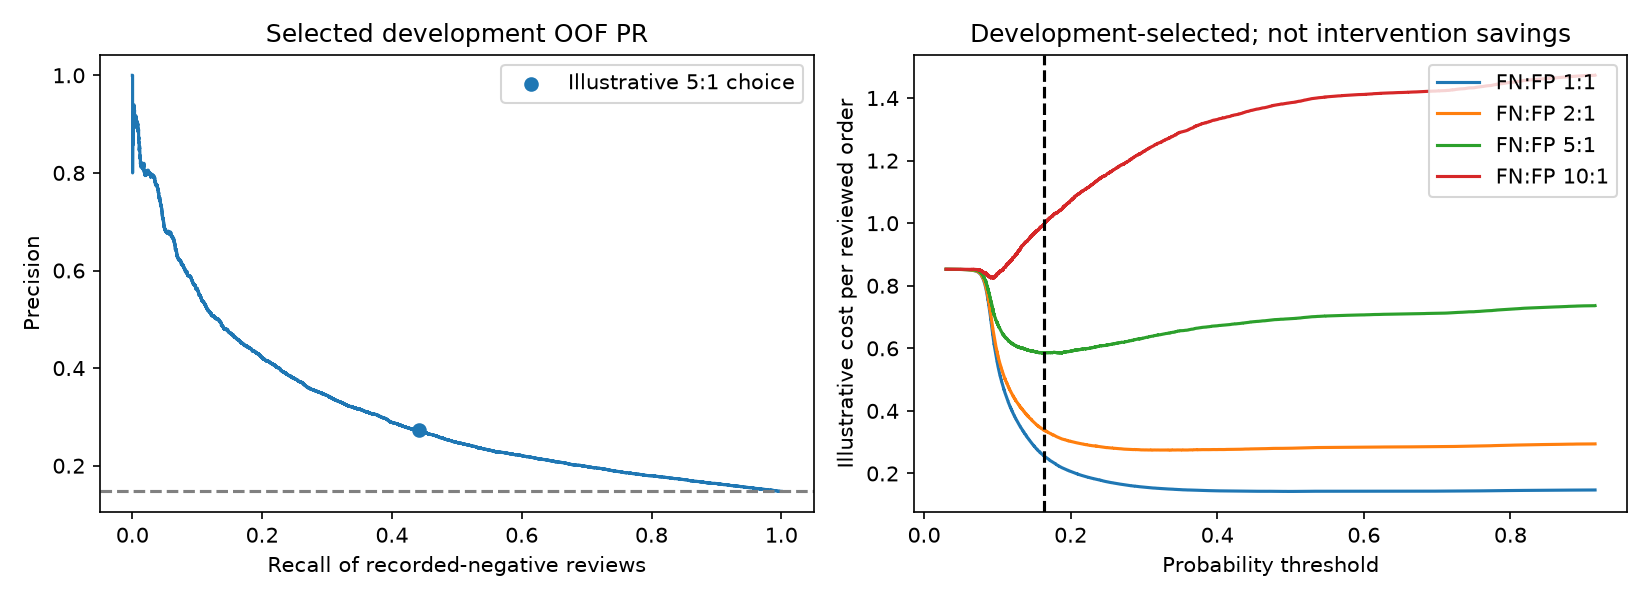

In [4]:
scenario = pd.read_csv(RUN / 'threshold_scenarios.csv')
display(scenario[['policy','cost_ratio_fn_to_fp','threshold','alerts','tp','fp','fn','tn','precision_1','recall_1','illustrative_cost']])
display(policy)
display(Image(filename=str(RUN / 'diagnostics/classification_policy_tradeoffs.png')))


## Availability sensitivity and predictive contribution

No-payment excludes all four payment predictors, not just their values. Item-bearing-only training inherits the same fold assignments and compares with the full model restricted to the same validation orders. It addresses a different population and does not establish that other fields truly existed at checkout. Interpret differences on matching rows only.

Joint feature-block permutation uses three repeats on at most 2,500 validation orders per fold, without refitting. Positive degradation suggests dependence on that block in this model/sample. Correlated groups can substitute and shuffling creates artificial combinations; do not describe it as causal importance. Numeric correlations/conditioning and baseline label sensitivity remain in Stage 3 evidence.


In [5]:
sensitivity = pd.read_csv(RUN / 'sensitivity_fold_metrics.csv')
for task, metric in config['primary_metrics'].items():
    display(sensitivity.loc[sensitivity.task.eq(task)].groupby(['variant','model_scope'])[metric].agg(['mean','std']))
importance = pd.read_csv(RUN / 'block_permutation_importance.csv')
display(importance.groupby(['task','block']).degradation.agg(['mean','std']).sort_values(['task','mean'], ascending=[True,False]))
stability = pd.read_csv(RUN / 'coefficient_stability.csv')
display(stability.loc[stability.folds_present.eq(5)].sort_values('std', ascending=False).head(15))


mean       std
variant           model_scope                                      
item_bearing_only full_model_matched_validation  0.263499  0.010394
                  sensitivity                    0.264087  0.010733
no_payment        full_model_matched_validation  0.311769  0.002933
                  sensitivity                    0.311171  0.003055

mean       std
variant    model_scope                                      
no_payment full_model_matched_validation  4.807863  0.067613
           sensitivity                    4.816218  0.068983

mean       std
task           block                        
classification basket     0.063816  0.021550
               calendar   0.042421  0.011682
               states     0.029627  0.010830
               distance   0.015296  0.007265
               financial  0.013954  0.008300
               physical   0.008209  0.005892
               category   0.001847  0.003143
               payment    0.000497  0.003574
regression     states     0.926372  0.090581
               calendar   0.643791  0.054151
               distance   0.577395  0.056299
               financial  0.158257  0.030682
               physical   0.064120  0.014660
               category   0.041847  0.011201
               payment    0.025751  0.010045
               basket     0.013244  0.007027

,task,candidate,feature,folds_present,mean,std,minimum,maximum,positive_folds,negative_folds
608,regression,ridge_a1,categorical__customer_state_RR,5,3.915333,2.300499,-0.099986,5.664162,4,1
705,regression,ridge_a1,categorical__primary_seller_state_RO,5,-2.130908,1.838823,-4.110308,-0.043959,0,5
698,regression,ridge_a1,categorical__primary_seller_state_PA,5,0.665039,1.605485,-1.411418,2.831004,4,1
697,regression,ridge_a1,categorical__primary_seller_state_MT,5,-2.800499,1.576795,-3.940113,-0.090694,0,5
696,regression,ridge_a1,categorical__primary_seller_state_MS,5,-3.587176,1.560758,-5.370348,-1.139168,0,5
699,regression,ridge_a1,categorical__primary_seller_state_PB,5,-5.914035,1.530090,-7.905585,-3.668876,0,5
689,regression,ridge_a1,categorical__primary_seller_state_BA,5,-2.231900,1.491834,-3.255951,0.403810,1,4
660,regression,ridge_a1,categorical__primary_category_home_comfort_2,5,1.738952,1.468219,-0.508024,3.285973,4,1
643,regression,ridge_a1,categorical__primary_category_fashion_children...,5,-0.859975,1.410105,-2.815466,1.162219,1,4
655,regression,ridge_a1,categorical__primary_category_furniture_mattre...,5,2.449188,1.388946,0.315185,3.734158,5,0


## Errors, coefficients and tree complexity

Residual-versus-predicted, distribution and Q–Q plots are diagnostics, not proofs of normality or mechanism. Coefficients are standardized numeric associations or categorical reference contrasts; exp(logistic coefficient) multiplies odds, not probability. Missing/rare levels and correlated predictors limit interpretation. Forests average bootstrap trees with randomized candidate features; their runtime/complexity is part of the comparison.


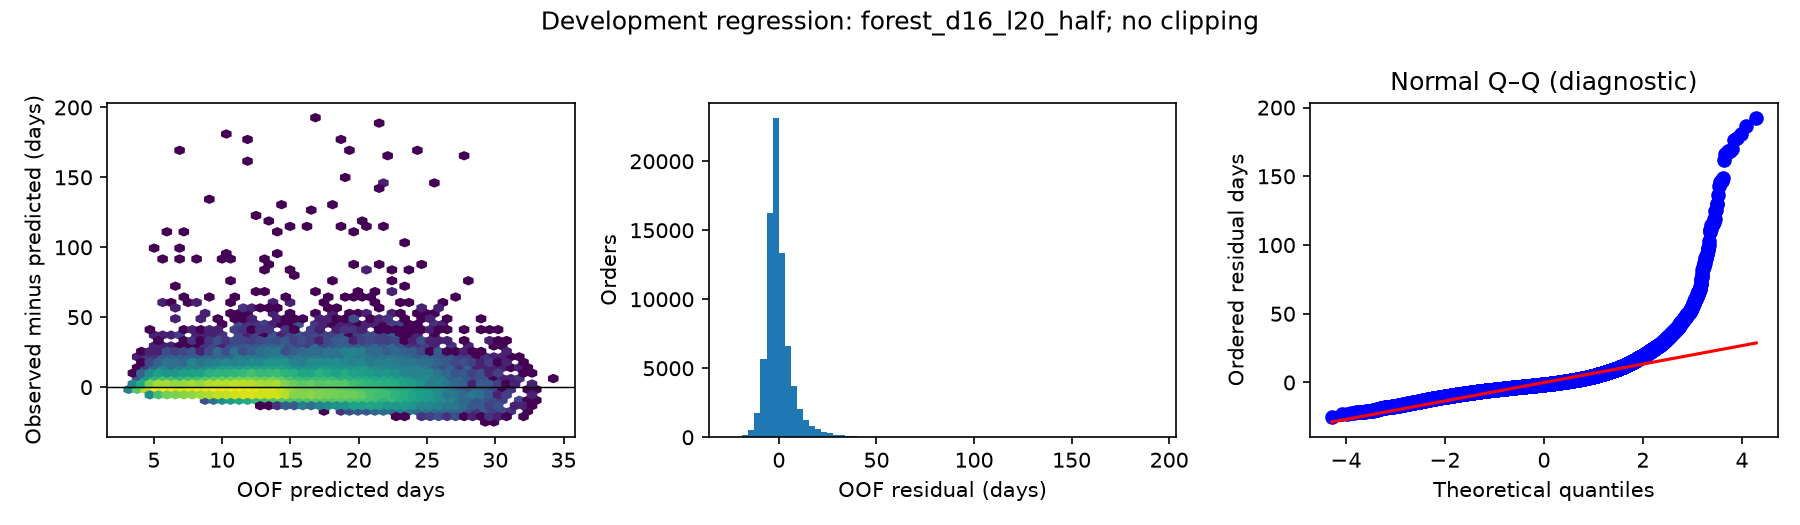

,task,model,feature,group,n,mae,rmse,r2,negative_predictions
0,regression,forest_d16_l20_half,customer_state,AC,72,6.354722,8.766324,0.099019,0
1,regression,forest_d16_l20_half,customer_state,AL,327,8.975653,11.811228,-0.048261,0
2,regression,forest_d16_l20_half,customer_state,AM,114,9.255426,15.043816,-0.000806,0
3,regression,forest_d16_l20_half,customer_state,AP,57,7.231833,9.244346,-0.223875,0
4,regression,forest_d16_l20_half,customer_state,BA,2560,6.840463,11.211378,0.098679,0
5,regression,forest_d16_l20_half,customer_state,CE,1039,7.162781,11.174597,0.173733,0
6,regression,forest_d16_l20_half,customer_state,DF,1687,4.991705,6.565074,0.131132,0
7,regression,forest_d16_l20_half,customer_state,ES,1614,5.656903,10.203920,0.071377,0
8,regression,forest_d16_l20_half,customer_state,GO,1600,4.933390,7.996173,0.104656,0
9,regression,forest_d16_l20_half,customer_state,MA,585,6.805923,11.027989,0.062249,0


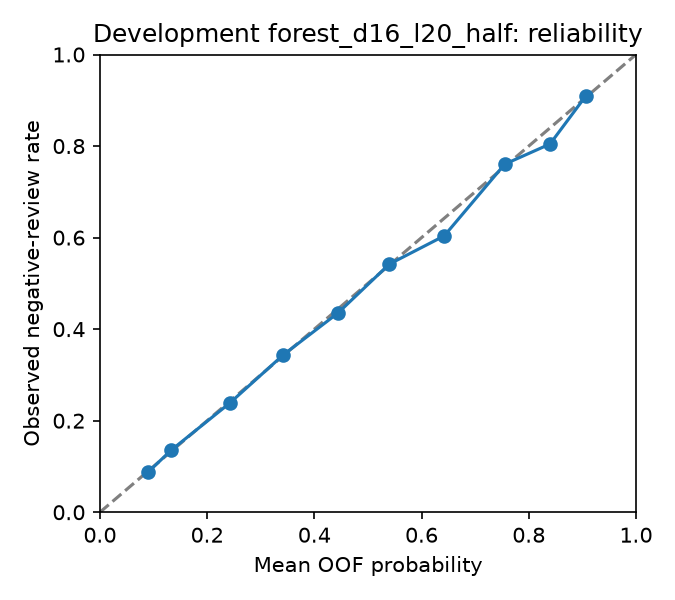

,task,model,feature,group,n,positives,negatives,prevalence,threshold,average_precision,...,f1_1,tn,fp,fn,tp,fpr,fnr,specificity,precision_defined,ranking_metrics_defined
0,classification,forest_d16_l20_half,customer_state,AC,73,11,62,0.150685,0.5,0.231693,...,0.000000,62,0,11,0,0.000000,1.000000,1.000000,False,True
1,classification,forest_d16_l20_half,customer_state,AL,336,81,255,0.241071,0.5,0.337129,...,0.000000,253,2,81,0,0.007843,1.000000,0.992157,True,True
2,classification,forest_d16_l20_half,customer_state,AM,115,17,98,0.147826,0.5,0.307178,...,0.111111,98,0,16,1,0.000000,0.941176,1.000000,True,True
3,classification,forest_d16_l20_half,customer_state,AP,57,4,53,0.070175,0.5,0.315912,...,0.000000,53,0,4,0,0.000000,1.000000,1.000000,False,True
4,classification,forest_d16_l20_half,customer_state,BA,2635,498,2137,0.188994,0.5,0.294944,...,0.072243,2128,9,479,19,0.004212,0.961847,0.995788,True,True
5,classification,forest_d16_l20_half,customer_state,CE,1067,201,866,0.188379,0.5,0.344817,...,0.074419,860,6,193,8,0.006928,0.960199,0.993072,True,True
6,classification,forest_d16_l20_half,customer_state,DF,1728,261,1467,0.151042,0.5,0.291795,...,0.106383,1461,6,246,15,0.004090,0.942529,0.995910,True,True
7,classification,forest_d16_l20_half,customer_state,ES,1622,253,1369,0.155980,0.5,0.307849,...,0.081181,1362,7,242,11,0.005113,0.956522,0.994887,True,True
8,classification,forest_d16_l20_half,customer_state,GO,1645,244,1401,0.148328,0.5,0.299140,...,0.128302,1397,4,227,17,0.002855,0.930328,0.997145,True,True
9,classification,forest_d16_l20_half,customer_state,MA,606,127,479,0.209571,0.5,0.331628,...,0.059701,476,3,123,4,0.006263,0.968504,0.993737,True,True


,task,candidate,fold,trees,bootstrap,max_features,mean_depth,mean_leaves
0,regression,forest_d8_l50_sqrt,0,64,True,sqrt,8.0,55.562500
1,regression,forest_d8_l50_sqrt,1,64,True,sqrt,8.0,53.093750
2,regression,forest_d8_l50_sqrt,2,64,True,sqrt,8.0,55.578125
3,regression,forest_d8_l50_sqrt,3,64,True,sqrt,8.0,53.203125
4,regression,forest_d8_l50_sqrt,4,64,True,sqrt,8.0,54.437500
5,regression,forest_d12_l20_half,0,64,True,0.5,12.0,501.156250
6,regression,forest_d12_l20_half,1,64,True,0.5,12.0,510.703125
7,regression,forest_d12_l20_half,2,64,True,0.5,12.0,499.937500
8,regression,forest_d12_l20_half,3,64,True,0.5,12.0,506.437500
9,regression,forest_d12_l20_half,4,64,True,0.5,12.0,517.890625


In [6]:
for task in ['regression','classification']:
    name = selection['tasks'][task]['candidate']['id']
    suffix = 'residuals' if task == 'regression' else 'reliability'
    display(Image(filename=str(RUN / f'diagnostics/{task}_{name}_{suffix}.png')))
    display(pd.read_csv(RUN / f'diagnostics/{task}_subgroup_metrics.csv').head(15))
fit_evidence = json.loads((RUN / 'fit_evidence.json').read_text())
forest_records = [r for r in fit_evidence if r['phase']=='search' and r.get('n_estimators')]
display(pd.DataFrame([{'task':r['task'],'candidate':r['candidate'],'fold':r['fold'],'trees':r['n_estimators'], 'bootstrap':r['bootstrap'],'max_features':r['max_features'], 'mean_depth':sum(r['depths'])/len(r['depths']), 'mean_leaves':sum(r['leaves'])/len(r['leaves'])} for r in forest_records]))


## Measured findings, frozen choice and review boundary

Both tasks select the depth-16 64-tree forest. Fold-mean MAE is 4.808 ± 0.068 days versus plain linear 4.993 ± 0.071; AP is 0.3118 ± 0.0029 versus plain logistic 0.2973 ± 0.0025. Every fold improves, but classification training AP around 0.451 versus validation 0.312 leaves a substantial gap. The depth-12 forest is only 0.00152 AP behind and cheaper; the declared rule prefers simpler families, not shallower settings within one family. This trade-off needs team review, not a significance claim.

No-payment results barely change (+0.0084 MAE days, −0.00060 AP). Review whether retaining payment assumptions is worthwhile before Stage 5; this diagnostic does not silently alter the 27-column primary contract. On identical item-bearing orders, full-model AP is 0.2635 and restricted-training AP 0.2641 versus matched Stage 3 logistic 0.2533. These are not comparable to full-cohort AP without a population caveat. Seller-state linear references also vary AC/AM between folds, so aggregated coefficient stability is not always an identical contrast.

The illustrative 5:1 policy uses probability >= 0.16387042604339028: 18,795 alerts, precision 0.2730 and recall 0.4413, compared with 1,095 alerts and recall 0.0626 at 0.5. That workload is about 23.8% of reviewed development orders, not an approved capacity or intervention saving. Read exact policy decisions from round-trip probabilities and authoritative JSON, without rounding. The highest reliability bin has only 11 orders.

The selection record binds configurations, features, versions, source hashes and the separately checksummed policy. Fold checkpoints are diagnostic models, not all-development final fits or deployment bundles. Minimum/first-review audit remains unchanged: 47 disagreements among 78,884 common orders, with a larger multi-review subgroup difference. The target remains any recorded negative review.

Stop after independent Stage 4 verification and team explanation/refinement review. Stage 5 performs final fit, protected holdout evaluation and final scoring bundles; Stage 6 produces the report/reproduction/submission audit. Never use holdout results to revise this selection.


In [7]:
display({task: selection['tasks'][task]['candidate'] for task in selection['tasks']})
display(selection['limitations'])
print('Selection record:', RUN / 'selection_record.json')
print('Decision policy:', RUN / 'decision_policy.json')
print('Independent Stage 4 verification and team explanation/refinement review:', 'pending')


{'classification': {'family': 'forest',
  'id': 'forest_d16_l20_half',
  'params': {'bootstrap': True,
   'max_depth': 16,
   'max_features': 0.5,
   'min_samples_leaf': 20,
   'n_estimators': 64}},
 'regression': {'family': 'forest',
  'id': 'forest_d16_l20_half',
  'params': {'bootstrap': True,
   'max_depth': 16,
   'max_features': 0.5,
   'min_samples_leaf': 20,
   'n_estimators': 64}}}

['CV scores and threshold performance are selected on development, not independent estimates',
 'mixed-time customer holdout does not estimate future drift',
 'snapshot availability remains unproven',
 'missing reviews are unknown; recorded negatives are not latent satisfaction',
 'sensitivity results do not silently change primary contract/cohort',
 'no final-fit deployment model exists']

Selection record: /Users/bensonwu/Projects/IT5006_GRP11/artifacts/metrics/stage4-selection-v1/selection_record.json
Decision policy: /Users/bensonwu/Projects/IT5006_GRP11/artifacts/metrics/stage4-selection-v1/decision_policy.json
Independent Stage 4 verification and team explanation/refinement review: pending
